# 06 — LSTM para S0 y S1

Ambas reutilizan `cargar_serie` / `partir_train_test` de `src/utils_ts.py` y
`construir_resultado` / `tabla_comparativa` de `src/evaluacion_modelos.py`,
con el mismo esquema `COLUMNAS_RESULTADOS` que ya usan ARIMA/Prophet/
Holt-Winters. Los campos que no aplican a LSTM (`AIC`, `BIC`, `Ljung_Box_p`,
`Jarque_Bera_p`) quedan en NaN.

## Sección S0

Entrena **2 configuraciones distintas de LSTM** para `S0_total`, cambiando
`lookback`, número de capas y `dropout` entre una y otra, con estrategia de
pronóstico recursivo multi-step: en ningún paso se usa el valor real de
prueba, igual que los modelos clásicos del Laboratorio 1.

In [1]:
from pathlib import Path
import sys

import pandas as pd

RAIZ = Path.cwd().resolve()
if RAIZ.name == "notebooks":
    RAIZ = RAIZ.parent
sys.path.insert(0, str(RAIZ / "src"))

from evaluacion_modelos import (
    COLUMNAS_RESULTADOS,
    construir_resultado,
    tabla_comparativa,
)
from modelos_lstm import (
    SEED,
    construir_modelo,
    crear_ventanas,
    entrenar_lstm,
    fijar_semillas,
    pronosticar_recursivo,
)
from utils_ts import cargar_serie, partir_train_test

DIR_RESULTADOS = RAIZ / "data" / "processed" / "resultados"
DIR_RESULTADOS.mkdir(parents=True, exist_ok=True)
RUTA_CSV_AVANCE = DIR_RESULTADOS / "lstm_avance_s0_s1.csv"

serie_s0 = cargar_serie("S0_total")
train_s0, test_s0 = partir_train_test(serie_s0)
print(f"S0_total -> train: {len(train_s0)} meses, test: {len(test_s0)} meses")

S0_total -> train: 147 meses, test: 63 meses


In [2]:
funciones_compartidas = [
    fijar_semillas,
    crear_ventanas,
    construir_modelo,
    pronosticar_recursivo,
    entrenar_lstm,
]
assert all(callable(funcion) for funcion in funciones_compartidas)
print("Funciones LSTM cargadas desde src/modelos_lstm.py")

Funciones LSTM cargadas desde src/modelos_lstm.py


### Dos configuraciones de partida, con al menos un hiperparámetro distinto

- **Config 1** (`LSTM-1capa-w12`): `lookback=12, unidades=50, capas=1,
  dropout=0.0` — una LSTM simple de una capa y ventana corta (un año).
- **Config 2** (`LSTM-2capas-w24`): `lookback=24, unidades=64, capas=2,
  dropout=0.2` — más profunda, con ventana más larga (dos años) y
  regularización por dropout.

Fijos en ambas: `epochs=100, batch_size=16, seed=SEED`. Los hiperparámetros
que cambian entre configuraciones son `lookback`, `capas` y `dropout`.

In [3]:
configuraciones_s0 = {
    "LSTM-1capa-w12": dict(lookback=12, unidades=50, capas=1, dropout=0.0),
    "LSTM-2capas-w24": dict(lookback=24, unidades=64, capas=2, dropout=0.2),
}

resultados_s0 = {}
filas_s0 = []
for nombre_modelo, parametros in configuraciones_s0.items():
    print(f"Entrenando {nombre_modelo}: {parametros}")
    resultado = entrenar_lstm(
        train_s0, test_s0, **parametros, epochs=100, batch_size=16, seed=SEED
    )
    resultados_s0[nombre_modelo] = resultado

    fila = construir_resultado(
        serie="S0_total",
        modelo=nombre_modelo,
        y_real=test_s0,
        y_pred=resultado["y_pred"],
        parametros={**parametros, "epochs": 100, "batch_size": 16},
        transformacion="MinMax(0,1)",
    )
    filas_s0.append(fila)
    print(f"  MAE={fila['MAE']:.2f}  RMSE={fila['RMSE']:.2f}  "
          f"MAPE={fila['MAPE']:.2f}%  "
          f"(épocas corridas: {len(resultado['historial'].history['loss'])})")

Entrenando LSTM-1capa-w12: {'lookback': 12, 'unidades': 50, 'capas': 1, 'dropout': 0.0}


  MAE=85372.61  RMSE=101262.73  MAPE=32.67%  (épocas corridas: 100)
Entrenando LSTM-2capas-w24: {'lookback': 24, 'unidades': 64, 'capas': 2, 'dropout': 0.2}


  MAE=39076.58  RMSE=50988.19  MAPE=23.44%  (épocas corridas: 56)


### Tabla comparativa y CSV del avance

Se guarda en `data/processed/resultados/lstm_avance_s0_s1.csv`.

In [4]:
if RUTA_CSV_AVANCE.exists():
    previo = pd.read_csv(RUTA_CSV_AVANCE)
    previo = previo[previo["serie"] != "S0_total"]
    filas_combinadas = pd.concat(
        [previo, pd.DataFrame(filas_s0)], ignore_index=True
    ).to_dict("records")
else:
    filas_combinadas = filas_s0

tabla_avance = tabla_comparativa(filas_combinadas)
tabla_avance.to_csv(RUTA_CSV_AVANCE, index=False)
tabla_avance[tabla_avance["serie"] == "S0_total"]

,serie,modelo,parametros,transformacion,AIC,BIC,MAE,RMSE,MAPE,Ljung_Box_p,Jarque_Bera_p,mejor_modelo
0,S0_total,LSTM-2capas-w24,"{'lookback': 24, 'unidades': 64, 'capas': 2, '...","MinMax(0,1)",NaN,NaN,39076.576124,50988.188584,23.436697,NaN,NaN,True
1,S0_total,LSTM-1capa-w12,"{'lookback': 12, 'unidades': 50, 'capas': 1, '...","MinMax(0,1)",NaN,NaN,85372.608951,101262.730670,32.672433,NaN,NaN,False


### Real vs. pronóstico de prueba, ambas configuraciones de S0

Solo para verificar visualmente que el pronóstico recursivo es razonable;
la selección del mejor modelo y la comparación contra el Laboratorio 1
quedan para la entrega final.

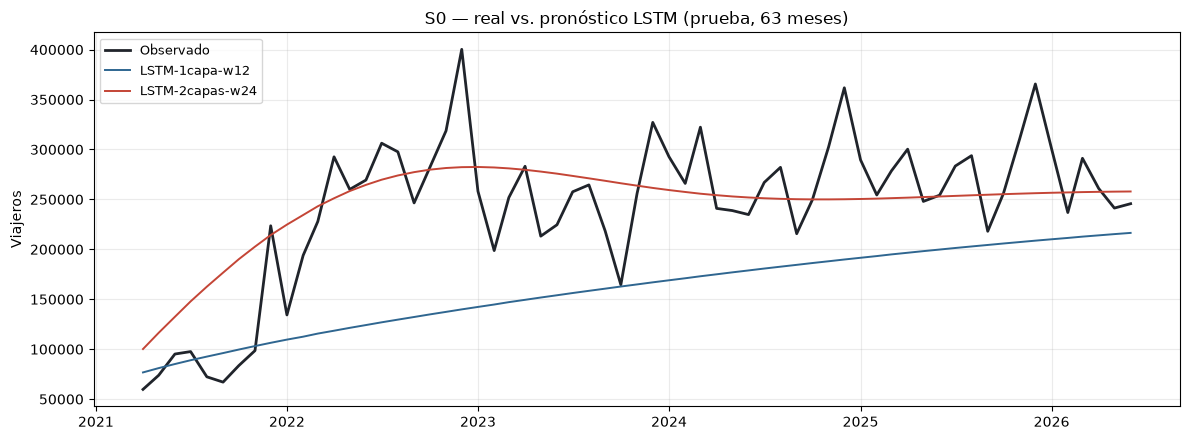

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(test_s0.index, test_s0.values, color="#20242b", linewidth=2.0,
        label="Observado")
colores = {"LSTM-1capa-w12": "#2f6690", "LSTM-2capas-w24": "#c44536"}
for nombre_modelo, resultado in resultados_s0.items():
    ax.plot(resultado["y_pred"].index, resultado["y_pred"].values,
            linewidth=1.4, color=colores[nombre_modelo], label=nombre_modelo)
ax.set_title("S0 — real vs. pronóstico LSTM (prueba, 63 meses)")
ax.set_ylabel("Viajeros")
ax.grid(alpha=0.25)
ax.legend(fontsize=9)
fig.tight_layout()
DIR_IMG = RAIZ / "informe" / "img"
DIR_IMG.mkdir(parents=True, exist_ok=True)
fig.savefig(DIR_IMG / "7_s0_lstm_avance.png", dpi=150, bbox_inches="tight")
plt.show()

### Cierre de la sección S0

- Se tunearon `lookback`, número de `capas` y `dropout` entre las dos
  configuraciones (ver tabla anterior para MAE/RMSE/MAPE exactos).
- El pronóstico es recursivo multi-step: en ningún paso se usa el valor
  real de prueba.
- El CSV queda guardado y el cuaderno es reproducible de principio a fin
  (semilla fija `SEED=42`).

### Selección del mejor modelo y comparación con el Laboratorio 1

Con las dos configuraciones ya entrenadas arriba, se arma `lstm_s0.csv` con
el mismo esquema `COLUMNAS_RESULTADOS` y se compara el mejor LSTM contra el
mejor modelo clásico de S0 del Laboratorio 1 (`metricas_s0_s5.csv`), usando
`combinar_metricas` sin escribir lógica nueva de comparación.

In [6]:
RUTA_LSTM_S0 = DIR_RESULTADOS / "lstm_s0.csv"
tabla_s0 = tabla_comparativa(filas_s0)
tabla_s0.to_csv(RUTA_LSTM_S0, index=False)
tabla_s0

,serie,modelo,parametros,transformacion,AIC,BIC,MAE,RMSE,MAPE,Ljung_Box_p,Jarque_Bera_p,mejor_modelo
0,S0_total,LSTM-2capas-w24,"{'lookback': 24, 'unidades': 64, 'capas': 2, '...","MinMax(0,1)",NaN,NaN,39076.576124,50988.188584,23.436697,NaN,NaN,True
1,S0_total,LSTM-1capa-w12,"{'lookback': 12, 'unidades': 50, 'capas': 1, '...","MinMax(0,1)",NaN,NaN,85372.608951,101262.730670,32.672433,NaN,NaN,False


In [7]:
mejor_fila_s0 = tabla_s0.loc[tabla_s0["mejor_modelo"]].iloc[0]
mejor_modelo_s0 = mejor_fila_s0["modelo"]
prediccion_mejor_s0 = resultados_s0[mejor_modelo_s0]["y_pred"]
print(f"Mejor LSTM para S0: {mejor_modelo_s0}")
print(f"MAE={mejor_fila_s0['MAE']:.2f}  RMSE={mejor_fila_s0['RMSE']:.2f}  "
      f"MAPE={mejor_fila_s0['MAPE']:.2f}%")

Mejor LSTM para S0: LSTM-2capas-w24
MAE=39076.58  RMSE=50988.19  MAPE=23.44%


In [8]:
from evaluacion_modelos import combinar_metricas

comparativo_s0 = combinar_metricas([
    str(DIR_RESULTADOS / "metricas_s0_s5.csv"),
    str(RUTA_LSTM_S0),
])
comparativo_s0[comparativo_s0["serie"] == "S0_total"][
    ["modelo", "MAE", "RMSE", "MAPE", "mejor_modelo"]
].sort_values("RMSE")

,modelo,MAE,RMSE,MAPE,mejor_modelo
0,LSTM-2capas-w24,39076.576124,50988.188584,23.436697,True
1,LSTM-1capa-w12,85372.608951,101262.730670,32.672433,False
2,Prophet,132304.357770,139548.643210,60.887434,False
3,"ARIMA(1,1,1)",154872.624803,169524.190145,59.301344,False
4,Suavizamiento exponencial simple,165372.541408,180598.233533,62.905913,False
5,Holt-Winters,176500.800901,189319.959428,69.170271,False
6,"auto_arima(2, 0, 0)x(1, 0, 1, 12)",183941.807170,198149.819240,72.246450,False
7,Seasonal Naive,207321.637396,219663.869357,84.910406,False
8,"SARIMA(1,1,1)(0,1,1,12)",213008.707051,227938.890271,84.091716,False
9,"SARIMA(2,1,1)(1,1,0,12)",222189.322037,241913.773817,84.570671,False


In [9]:
pronosticos_clasicos_s0 = pd.read_csv(DIR_RESULTADOS / "pronosticos_s0_s5.csv")
nombres_clasicos_s0 = set(
    pronosticos_clasicos_s0.loc[
        pronosticos_clasicos_s0["serie"] == "S0_total", "modelo"
    ]
)
mejor_clasico_fila = (
    comparativo_s0[
        (comparativo_s0["serie"] == "S0_total")
        & (comparativo_s0["modelo"].isin(nombres_clasicos_s0))
    ]
    .sort_values("RMSE")
    .iloc[0]
)
mejor_clasico_nombre = mejor_clasico_fila["modelo"]
pronostico_mejor_clasico = (
    pronosticos_clasicos_s0[
        (pronosticos_clasicos_s0["serie"] == "S0_total")
        & (pronosticos_clasicos_s0["modelo"] == mejor_clasico_nombre)
    ]
    .assign(fecha=lambda d: pd.to_datetime(d["fecha"]))
    .set_index("fecha")["pronostico"]
)

supera_al_clasico = mejor_fila_s0["RMSE"] < mejor_clasico_fila["RMSE"]
print(f"Mejor modelo clásico de S0 (Laboratorio 1): {mejor_clasico_nombre}")
print(f"MAE={mejor_clasico_fila['MAE']:.2f}  RMSE={mejor_clasico_fila['RMSE']:.2f}  "
      f"MAPE={mejor_clasico_fila['MAPE']:.2f}%")
print(f"¿El mejor LSTM superó al mejor clásico por RMSE? {supera_al_clasico}")

Mejor modelo clásico de S0 (Laboratorio 1): Prophet
MAE=132304.36  RMSE=139548.64  MAPE=60.89%
¿El mejor LSTM superó al mejor clásico por RMSE? True


### Real vs. mejor LSTM vs. mejor modelo clásico

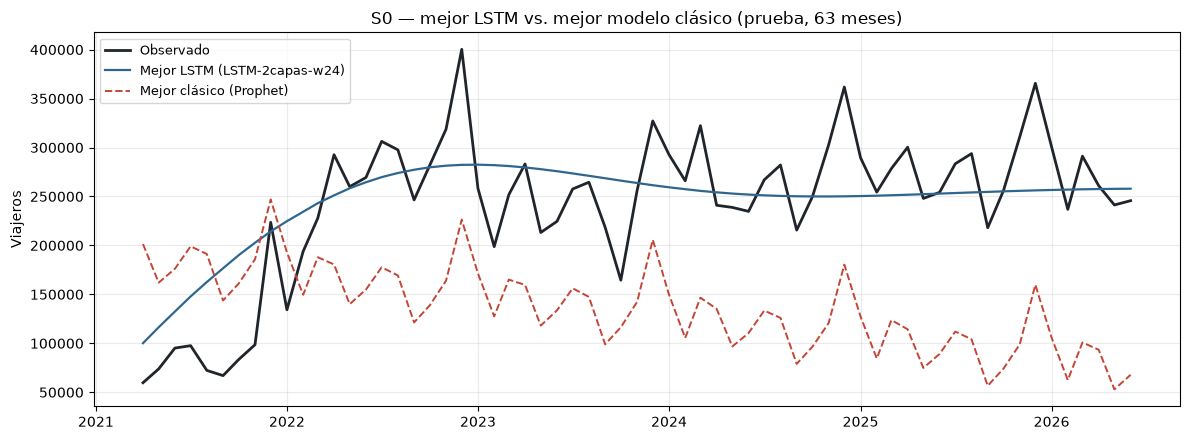

In [10]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(test_s0.index, test_s0.values, color="#20242b", linewidth=2.0,
        label="Observado")
ax.plot(prediccion_mejor_s0.index, prediccion_mejor_s0.values,
        color="#2f6690", linewidth=1.6,
        label=f"Mejor LSTM ({mejor_modelo_s0})")
ax.plot(pronostico_mejor_clasico.index, pronostico_mejor_clasico.values,
        color="#c44536", linewidth=1.4, linestyle="--",
        label=f"Mejor clásico ({mejor_clasico_nombre})")
ax.set_title("S0 — mejor LSTM vs. mejor modelo clásico (prueba, 63 meses)")
ax.set_ylabel("Viajeros")
ax.grid(alpha=0.25)
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(DIR_IMG / "9_s0_lstm_vs_clasico.png", dpi=150, bbox_inches="tight")
plt.show()

### Cierre de la entrega final para S0

- El mejor LSTM de S0 se determina por menor RMSE en prueba entre las dos
  configuraciones tuneadas (ver tabla de `lstm_s0.csv` arriba).
- Se compara contra el mejor modelo clásico de S0 del Laboratorio 1 con
  `combinar_metricas`, sin recalcular métricas a mano.
- La gráfica confirma visualmente si el LSTM se acerca más al patrón
  observado que el mejor pronóstico clásico durante los 63 meses de prueba.
- El detalle numérico completo y la interpretación quedan en
  `informe/secciones/09_lstm_s0.md`.

## Sección S1

Entrena **2 configuraciones distintas de LSTM** para `S1_la_aurora`. La
sección reutiliza las funciones consolidadas en `src/modelos_lstm.py`. El
escalador se ajusta solo con entrenamiento y el pronóstico de los 63 meses
de prueba es completamente recursivo, sin incorporar observaciones reales.

In [11]:
# Preparación independiente de S1 con las utilidades del Laboratorio 1.
serie_s1 = cargar_serie("S1_la_aurora")
train_s1, test_s1 = partir_train_test(serie_s1)

assert len(train_s1) == 147 and len(test_s1) == 63
assert train_s1.index.max() < test_s1.index.min()
print(f"S1_la_aurora -> train: {len(train_s1)} meses, "
      f"test: {len(test_s1)} meses")

S1_la_aurora -> train: 147 meses, test: 63 meses


In [12]:
assert all(callable(funcion) for funcion in funciones_compartidas)
print("S1 reutilizará las funciones de src/modelos_lstm.py")

S1 reutilizará las funciones de src/modelos_lstm.py


### Tuneo de hiperparámetros para S1

- **Config 1** (`LSTM-1capa-w12`): `lookback=12`, `unidades=50`, `capas=1`,
  `dropout=0.0`. Usa un año de historia y una arquitectura simple.
- **Config 2** (`LSTM-2capas-w24`): `lookback=24`, `unidades=64`, `capas=2`,
  `dropout=0.2`. Usa dos años, mayor capacidad y regularización.

En ambas se mantienen `epochs=100`, `batch_size=16` y `seed=42`. Por tanto,
se tunean explícitamente la ventana, las unidades, la profundidad y el
dropout.

In [13]:
configuraciones_s1 = {
    "LSTM-1capa-w12": dict(lookback=12, unidades=50, capas=1, dropout=0.0),
    "LSTM-2capas-w24": dict(lookback=24, unidades=64, capas=2, dropout=0.2),
}

resultados_s1 = {}
filas_s1 = []
for nombre_modelo, parametros in configuraciones_s1.items():
    print(f"Entrenando S1 / {nombre_modelo}: {parametros}")
    resultado = entrenar_lstm(
        train_s1, test_s1, **parametros,
        epochs=100, batch_size=16, seed=SEED,
    )
    resultados_s1[nombre_modelo] = resultado

    fila = construir_resultado(
        serie="S1_la_aurora",
        modelo=nombre_modelo,
        y_real=test_s1,
        y_pred=resultado["y_pred"],
        parametros={**parametros, "epochs": 100, "batch_size": 16},
        transformacion="MinMax(0,1)",
    )
    filas_s1.append(fila)
    epocas = len(resultado["historial"].history["loss"])
    print(f"  MAE={fila['MAE']:.2f}  RMSE={fila['RMSE']:.2f}  "
          f"MAPE={fila['MAPE']:.2f}%  (épocas corridas: {epocas})")

Entrenando S1 / LSTM-1capa-w12: {'lookback': 12, 'unidades': 50, 'capas': 1, 'dropout': 0.0}


  MAE=17851.22  RMSE=23957.66  MAPE=18.30%  (épocas corridas: 100)
Entrenando S1 / LSTM-2capas-w24: {'lookback': 24, 'unidades': 64, 'capas': 2, 'dropout': 0.2}


  MAE=14872.79  RMSE=18998.20  MAPE=18.25%  (épocas corridas: 56)


### Consolidación de métricas S0 + S1

La actualización elimina únicamente resultados S1 anteriores y conserva las
filas S0 existentes. Después aplica `tabla_comparativa` para
mantener el esquema común y marcar el menor RMSE dentro de cada serie.

In [14]:
if RUTA_CSV_AVANCE.exists():
    previo = pd.read_csv(RUTA_CSV_AVANCE)
    previo = previo[previo["serie"] != "S1_la_aurora"]
    filas_combinadas = pd.concat(
        [previo, pd.DataFrame(filas_s1)], ignore_index=True
    ).to_dict("records")
else:
    filas_combinadas = filas_s1

tabla_avance = tabla_comparativa(filas_combinadas)

conteos = tabla_avance.groupby("serie").size().to_dict()
assert list(tabla_avance.columns) == COLUMNAS_RESULTADOS
assert conteos == {"S0_total": 2, "S1_la_aurora": 2}
assert not tabla_avance.duplicated(["serie", "modelo"]).any()
assert tabla_avance.groupby("serie")["mejor_modelo"].sum().eq(1).all()

tabla_avance.to_csv(RUTA_CSV_AVANCE, index=False)
print("Validación: 4 modelos, 2 por serie, sin duplicados.")
tabla_avance[tabla_avance["serie"] == "S1_la_aurora"]

Validación: 4 modelos, 2 por serie, sin duplicados.


,serie,modelo,parametros,transformacion,AIC,BIC,MAE,RMSE,MAPE,Ljung_Box_p,Jarque_Bera_p,mejor_modelo
2,S1_la_aurora,LSTM-2capas-w24,"{'lookback': 24, 'unidades': 64, 'capas': 2, '...","MinMax(0,1)",NaN,NaN,14872.791793,18998.198498,18.248489,NaN,NaN,True
3,S1_la_aurora,LSTM-1capa-w12,"{'lookback': 12, 'unidades': 50, 'capas': 1, '...","MinMax(0,1)",NaN,NaN,17851.218547,23957.664894,18.296391,NaN,NaN,False


### Real vs. pronóstico de prueba para S1

La gráfica permite comprobar visualmente el comportamiento de las dos
configuraciones durante los mismos 63 meses de prueba.

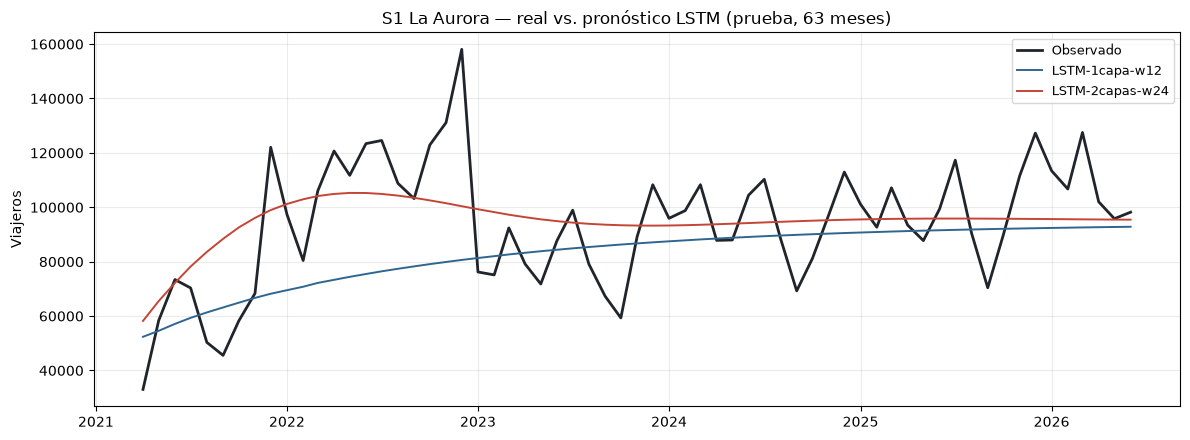

In [15]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(test_s1.index, test_s1.values, color="#20242b", linewidth=2.0,
        label="Observado")
colores_s1 = {
    "LSTM-1capa-w12": "#2f6690",
    "LSTM-2capas-w24": "#c44536",
}
for nombre_modelo, resultado in resultados_s1.items():
    ax.plot(
        resultado["y_pred"].index,
        resultado["y_pred"].values,
        linewidth=1.4,
        color=colores_s1[nombre_modelo],
        label=nombre_modelo,
    )
ax.set_title("S1 La Aurora — real vs. pronóstico LSTM (prueba, 63 meses)")
ax.set_ylabel("Viajeros")
ax.grid(alpha=0.25)
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(DIR_IMG / "8_s1_lstm_avance.png", dpi=150, bbox_inches="tight")
plt.show()

### Cierre de la sección S1

- Se entrenaron dos LSTM para `S1_la_aurora` con cambios explícitos en
  `lookback`, `unidades`, `capas` y `dropout`.
- `MinMaxScaler` se ajustó exclusivamente con los 147 meses de entrenamiento.
- Las 63 predicciones son recursivas y están alineadas con el índice de prueba.
- Las métricas MAE, RMSE y MAPE se guardaron junto con los parámetros en el
  CSV consolidado, sin reemplazar las filas de S0.

### Selección del mejor modelo y comparación con el Laboratorio 1

Las dos configuraciones se ordenan por RMSE de prueba y se exportan con el
esquema común de resultados. Después se comparan con los modelos clásicos
de `S1_la_aurora` evaluados sobre la misma partición de 147/63 meses.

In [16]:
RUTA_LSTM_S1 = DIR_RESULTADOS / "lstm_s1.csv"
tabla_s1 = tabla_comparativa(filas_s1)

assert len(tabla_s1) == 2
assert tabla_s1["serie"].eq("S1_la_aurora").all()
assert tabla_s1["mejor_modelo"].sum() == 1
tabla_s1.to_csv(RUTA_LSTM_S1, index=False)
tabla_s1

,serie,modelo,parametros,transformacion,AIC,BIC,MAE,RMSE,MAPE,Ljung_Box_p,Jarque_Bera_p,mejor_modelo
0,S1_la_aurora,LSTM-2capas-w24,"{'lookback': 24, 'unidades': 64, 'capas': 2, '...","MinMax(0,1)",NaN,NaN,14872.791793,18998.198498,18.248489,NaN,NaN,True
1,S1_la_aurora,LSTM-1capa-w12,"{'lookback': 12, 'unidades': 50, 'capas': 1, '...","MinMax(0,1)",NaN,NaN,17851.218547,23957.664894,18.296391,NaN,NaN,False


In [17]:
mejor_fila_s1 = tabla_s1.loc[tabla_s1["mejor_modelo"]].iloc[0]
mejor_modelo_s1 = mejor_fila_s1["modelo"]
prediccion_mejor_s1 = resultados_s1[mejor_modelo_s1]["y_pred"]

assert len(prediccion_mejor_s1) == len(test_s1) == 63
assert prediccion_mejor_s1.index.equals(test_s1.index)
print(f"Mejor LSTM para S1: {mejor_modelo_s1}")
print(f"MAE={mejor_fila_s1['MAE']:.2f}  "
      f"RMSE={mejor_fila_s1['RMSE']:.2f}  "
      f"MAPE={mejor_fila_s1['MAPE']:.2f}%")

Mejor LSTM para S1: LSTM-2capas-w24
MAE=14872.79  RMSE=18998.20  MAPE=18.25%


In [18]:
comparativo_s1 = combinar_metricas([
    str(DIR_RESULTADOS / "metricas_s1_s2_s6.csv"),
    str(RUTA_LSTM_S1),
])
comparativo_s1[comparativo_s1["serie"] == "S1_la_aurora"][
    ["modelo", "MAE", "RMSE", "MAPE", "mejor_modelo"]
].sort_values("RMSE")

,modelo,MAE,RMSE,MAPE,mejor_modelo
0,LSTM-2capas-w24,14872.791793,18998.198498,18.248489,True
1,LSTM-1capa-w12,17851.218547,23957.664894,18.296391,False
2,"ARIMA(1,1,1)",33049.417475,38249.073932,33.081138,False
3,"ARIMA(0,1,1)",33467.501247,38659.131478,33.421138,False
4,"ARIMA(1,1,0)",34250.386585,39443.895861,34.144109,False
5,Suavizamiento exponencial simple,36821.786048,42053.317869,36.563063,False
6,Holt-Winters,38903.906084,42886.686325,39.492143,False
7,Prophet,45973.056930,50962.928036,47.474829,False
8,"SARIMA(1,1,1)(0,1,1,12)",68210.158705,72421.310311,71.993488,False
9,"auto_arima(1, 0, 1)x(1, 0, 1, 12)",71902.883567,75900.743829,76.289279,False


In [19]:
pronosticos_clasicos_s1 = pd.read_csv(
    DIR_RESULTADOS / "pronosticos_s1_s2_s6.csv"
)
nombres_clasicos_s1 = set(
    pronosticos_clasicos_s1.loc[
        pronosticos_clasicos_s1["serie"] == "S1_la_aurora", "modelo"
    ]
)
mejor_clasico_fila_s1 = (
    comparativo_s1[
        (comparativo_s1["serie"] == "S1_la_aurora")
        & (comparativo_s1["modelo"].isin(nombres_clasicos_s1))
    ]
    .sort_values("RMSE")
    .iloc[0]
)
mejor_clasico_nombre_s1 = mejor_clasico_fila_s1["modelo"]
pronostico_mejor_clasico_s1 = (
    pronosticos_clasicos_s1[
        (pronosticos_clasicos_s1["serie"] == "S1_la_aurora")
        & (pronosticos_clasicos_s1["modelo"] == mejor_clasico_nombre_s1)
    ]
    .assign(fecha=lambda datos: pd.to_datetime(datos["fecha"]))
    .set_index("fecha")["pronostico"]
)

assert len(pronostico_mejor_clasico_s1) == 63
assert pronostico_mejor_clasico_s1.index.equals(test_s1.index)
otra_lstm_s1 = tabla_s1.loc[~tabla_s1["mejor_modelo"]].iloc[0]
reduccion_rmse_entre_lstm = (
    1 - mejor_fila_s1["RMSE"] / otra_lstm_s1["RMSE"]
) * 100
reduccion_rmse_vs_clasico = (
    1 - mejor_fila_s1["RMSE"] / mejor_clasico_fila_s1["RMSE"]
) * 100
print(f"Mejor modelo clásico de S1: {mejor_clasico_nombre_s1}")
print(f"MAE={mejor_clasico_fila_s1['MAE']:.2f}  "
      f"RMSE={mejor_clasico_fila_s1['RMSE']:.2f}  "
      f"MAPE={mejor_clasico_fila_s1['MAPE']:.2f}%")
print(f"Reducción de RMSE entre LSTM: {reduccion_rmse_entre_lstm:.2f}%")
print(f"Reducción de RMSE frente al clásico: "
      f"{reduccion_rmse_vs_clasico:.2f}%")

Mejor modelo clásico de S1: ARIMA(1,1,1)
MAE=33049.42  RMSE=38249.07  MAPE=33.08%
Reducción de RMSE entre LSTM: 20.70%
Reducción de RMSE frente al clásico: 50.33%


### Real vs. mejor LSTM vs. mejor modelo clásico

La comparación visual usa exactamente los mismos 63 meses de prueba para
los valores observados y ambos pronósticos.

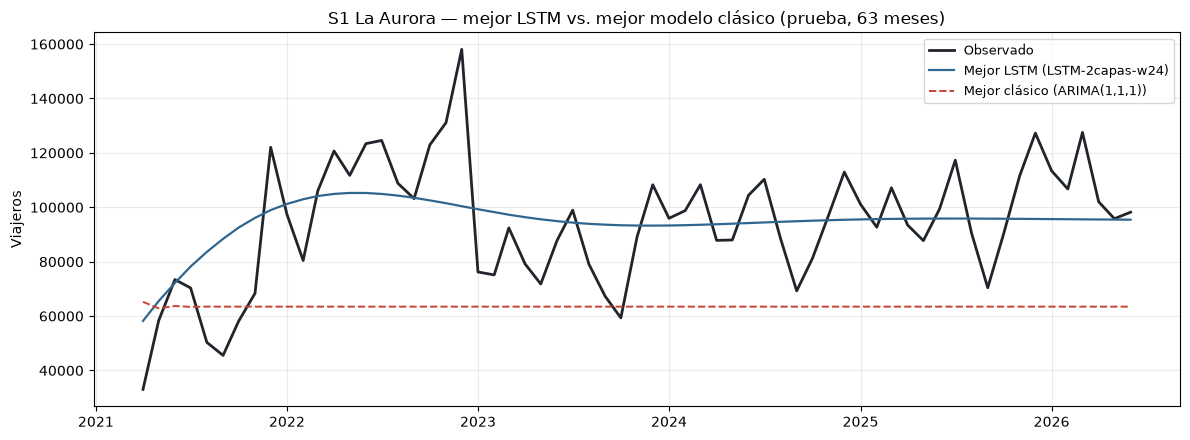

In [20]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(test_s1.index, test_s1.values, color="#20242b", linewidth=2.0,
        label="Observado")
ax.plot(prediccion_mejor_s1.index, prediccion_mejor_s1.values,
        color="#2f6690", linewidth=1.6,
        label=f"Mejor LSTM ({mejor_modelo_s1})")
ax.plot(pronostico_mejor_clasico_s1.index,
        pronostico_mejor_clasico_s1.values,
        color="#c44536", linewidth=1.4, linestyle="--",
        label=f"Mejor clásico ({mejor_clasico_nombre_s1})")
ax.set_title("S1 La Aurora — mejor LSTM vs. mejor modelo clásico "
             "(prueba, 63 meses)")
ax.set_ylabel("Viajeros")
ax.grid(alpha=0.25)
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(DIR_IMG / "10_s1_lstm_vs_clasico.png",
            dpi=150, bbox_inches="tight")
plt.show()

### Cierre de la entrega final para S1

- El mejor LSTM se elige exclusivamente por menor RMSE en los 63 meses de
  prueba, manteniendo MAE y MAPE como métricas complementarias.
- La comparación clásica usa el modelo con menor RMSE de S1 en el
  Laboratorio 1 y la misma partición temporal.
- Las conclusiones se limitan al desempeño observado de cada configuración;
  no se atribuye la mejora a un hiperparámetro aislado porque varios
  cambiaron al mismo tiempo.
- El detalle numérico y la interpretación se presentan en
  `informe/secciones/10_lstm_s1.md`.